In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import zscore
from aind_dynamic_foraging_data_utils.nwb_utils import load_nwb_from_filename

def nwb_path(data_dir, filename):
    # DANDI structure: 001950/sub-{id}/sub-{id}_ses-behavior-{id}-{datetime}.nwb
    subject = filename.split('_ses-')[0]  # e.g. 'sub-754896'
    return str(Path(data_dir) / '001950' / subject / filename)

In [64]:
data_dir = "C:\\Users\\zhixi\\Documents\\data\\dandi_data"

In [ ]:
# Update to the DANDI filename for your chosen session (browse dandiarchive.org/dandiset/001950)
# Format: sub-{id}_ses-behavior-{id}-{YYYY}-{MM}-{DD}-{HH}-{MM}-{SS}.nwb
example_beh = 'sub-669489_ses-behavior-669489-2023-06-24-14-56-01.nwb'

In [ ]:
example_pupil = 'sub-669492_ses-behavior-669492-2023-06-26-16-23-02.nwb'  # session with pupil data

In [ ]:
example_FP = 'sub-754896_ses-behavior-754896-2025-01-03-17-20-19.nwb'  # 754896 used in F_photometry_examples

In [ ]:
example_ephys = 'sub-754897_ses-behavior-754897-2025-03-13-11-20-42.nwb'  # used in F_cross_correlation / F_ephys_behavior_examples

## 1. Behavior — raw session (smoothed choice, reward, block structure)

Data location: `nwb.intervals['trials']` (or `nwb.trials`)  

386 trials


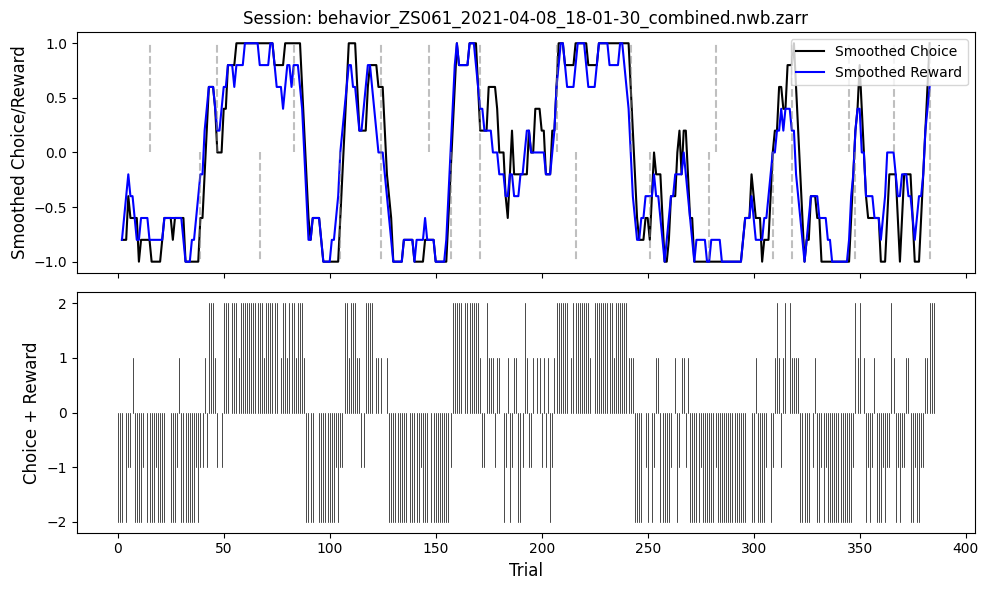

In [69]:
nwb_beh = load_nwb_from_filename(nwb_path(data_dir, example_beh))
trials = nwb_beh.trials.to_dataframe()
print(f'{len(trials)} trials')

# ── choices: right=+1, left=-1, no-response=0  (mirrors makeSessionDF) ────
choices = np.where(trials['animal_response'] == 1, 1.0,
          np.where(trials['animal_response'] == 0, -1.0, 0.0))

# ── rewarded, signed by choice direction ──────────────────────────────────
rewarded = (trials['rewarded_historyL'] | trials['rewarded_historyR']).astype(float)
rwds = rewarded * choices   # +1 rewarded-right, -1 rewarded-left, 0 not rewarded

# ── 5-point moving average (same kernel as Figure4b) ─────────────────────
kernel = np.ones(5) / 5
smoothedChoice = np.convolve(choices, kernel, mode='full')[2:-2]
smoothedRwd    = np.convolve(rwds,    kernel, mode='full')[2:-2]
smoothedChoice[:2] = smoothedRwd[:2] = np.nan
smoothedChoice[-2:] = smoothedRwd[-2:] = np.nan

# ── block transitions ──────────────────────────────────────────────────────
block_change_L = np.where(np.diff(trials['reward_probabilityL'].values) != 0)[0] + 1
block_change_R = np.where(np.diff(trials['reward_probabilityR'].values) != 0)[0] + 1

# ── plot (exact Figure4b layout) ──────────────────────────────────────────
fig, ax = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

ax[0].plot(smoothedChoice, color='k')
ax[0].plot(smoothedRwd, color='b')
ax[0].legend(['Smoothed Choice', 'Smoothed Reward'], fontsize=10)
ax[0].set_ylabel('Smoothed Choice/Reward', fontsize=12)
ax[0].set_title(f'Session: {example_beh}', fontsize=12)

# gray bars at block transitions (down for L, up for R)
for bc in block_change_L:
    ax[0].plot([bc, bc], [0, -1], color='gray', linestyle='--', alpha=0.5)
for bc in block_change_R:
    ax[0].plot([bc, bc], [0,  1], color='gray', linestyle='--', alpha=0.5)

# per-trial black bars: length encodes choice + outcome
for i in range(len(trials)):
    ax[1].plot([i, i], [0, choices[i] + rwds[i]], color='k', alpha=1, linewidth=0.5)

ax[1].set_ylabel('Choice + Reward', fontsize=12)
ax[1].set_xlabel('Trial', fontsize=12)

plt.tight_layout()
plt.show()

## 2. Pupil — raw trace + go-cue-aligned PSTH (go vs no-go)

Data location: `nwb.processing`  

In [70]:
nwb_pupil = load_nwb_from_filename(nwb_path(data_dir, example_pupil))
trials_pupil = nwb_pupil.trials.to_dataframe()

# ── explore processing structure ───────────────────────────────────────────
print('Processing modules:')
for pm_name, pm in nwb_pupil.processing.items():
    print(f'  {pm_name}:')
    for k, v in pm.data_interfaces.items():
        print(f'    {k}: {type(v).__name__}')

Processing modules:
  behavior:
    pupil_diameter: TimeSeries


Using unit TT6_SS_02 (19591 spikes)


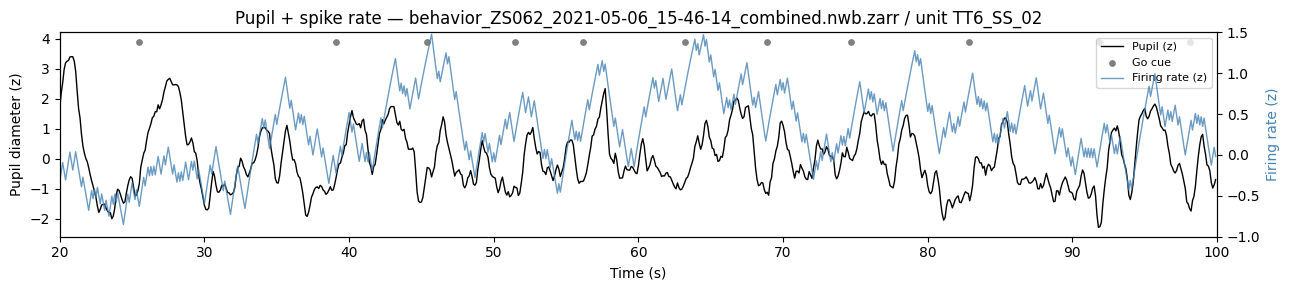

In [71]:
# ── load pupil timeseries ─────────────────────────────────────────────────
pupil_module = nwb_pupil.processing['behavior']
pupil_ts = pupil_module['pupil_diameter']
pupil_times = pupil_ts.timestamps[:]
pupil_vals  = pupil_ts.data[:]

# ── load units for the same session ───────────────────────────────────────
units_pupil = nwb_pupil.units.to_dataframe()
spike_counts = units_pupil['spike_times'].apply(len)
best_unit = spike_counts.idxmax()
spike_times_pupil = units_pupil.loc[best_unit, 'spike_times']
unit_id_pupil = units_pupil.loc[best_unit, 'unit_id']
print(f'Using unit {unit_id_pupil} ({len(spike_times_pupil)} spikes)')

# ── 100 s window starting at trial 12 ─────────────────────────────────────
t0 = trials_pupil['goCue_start_time'].values[12] - 2
t1 = t0 + 100

# ── smooth spike rate (PSP kernel: tau_rise=1ms, tau_decay=5s) ────────────
step = 0.1
t_ax = np.arange(t0, t1, step)
tau_r, tau_d = 0.001, 5.0
kernel_t = np.arange(0, 5 * tau_d, step)
psp = np.exp(-kernel_t / tau_d) - np.exp(-kernel_t / tau_r)
psp /= psp.sum() * step
spike_train = np.zeros(len(t_ax))
for s in spike_times_pupil:
    idx = int((s - t0) / step)
    if 0 <= idx < len(spike_train):
        spike_train[idx] = 1
fr_smooth = np.convolve(spike_train / step, psp * step, mode='full')[:len(t_ax)]
fr_z = zscore(fr_smooth, nan_policy='omit')

# ── bin pupil into same time grid ─────────────────────────────────────────
pupil_binned = np.full(len(t_ax), np.nan)
for i, t in enumerate(t_ax):
    mask = (pupil_times >= t) & (pupil_times < t + step)
    if mask.any():
        pupil_binned[i] = np.nanmean(pupil_vals[mask])
pupil_z = zscore(pupil_binned, nan_policy='omit')

go_cues_win = trials_pupil['goCue_start_time'].values
go_cues_win = go_cues_win[(go_cues_win > t0) & (go_cues_win < t1)]

# ── plot: dual-axis pupil + spike rate (both z-scored) ────────────────────
fig, ax1 = plt.subplots(figsize=(13, 3))
ax1.plot(t_ax - t0, pupil_z, color='k', lw=1, label='Pupil (z)')
ax1.scatter(go_cues_win - t0, np.full(len(go_cues_win), pupil_z[~np.isnan(pupil_z)].max() + 0.5),
            color='gray', marker='o', s=15, label='Go cue')
ax1.set_ylabel('Pupil diameter (z)', color='k')
ax1.set_xlabel('Time (s)')
ax1.set_title(f'Pupil + spike rate — {example_pupil} / unit {unit_id_pupil}')

ax2 = ax1.twinx()
ax2.plot(t_ax - t0, fr_z, color='steelblue', lw=1, alpha=0.8, label='Firing rate (z)')
ax2.set_ylabel('Firing rate (z)', color='steelblue')
ax2.set_xlim(20, t1 - t0)
ax2.set_ylim(-1, 1.5)

lines1, lab1 = ax1.get_legend_handles_labels()
lines2, lab2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, lab1 + lab2, fontsize=8)
ax1.set_xlim(20, t1 - t0)
plt.tight_layout()
plt.show()

In [ ]:
example_pupil_psth = 'sub-669489_ses-behavior-669489-2023-06-24-14-56-01.nwb'

nwb_pupil_psth  = load_nwb_from_filename(nwb_path(data_dir, example_pupil_psth))
trials_psth     = nwb_pupil_psth.trials.to_dataframe()
pupil_ts_psth   = nwb_pupil_psth.processing['behavior']['pupil_diameter']
pupil_times_psth = pupil_ts_psth.timestamps[:]
pupil_vals_psth  = pupil_ts_psth.data[:]
pupil_z_psth = zscore(pupil_vals_psth, nan_policy='omit')

# ── go-cue-aligned pupil PSTH: go vs no-go ───────────────────────────────
def align_to_events(values, times, events, t_pre, t_post, bin_size):
    bins = np.arange(t_pre, t_post, bin_size)
    mat = np.full((len(events), len(bins)), np.nan)
    for i, ev in enumerate(events):
        for j, b in enumerate(bins):
            mask = (times >= ev + b) & (times < ev + b + bin_size)
            if mask.any():
                mat[i, j] = np.nanmean(values[mask])
    return mat, bins + bin_size / 2

go_times   = trials_psth.loc[trials_psth['animal_response'] != 2, 'goCue_start_time'].values
nogo_times = trials_psth.loc[trials_psth['animal_response'] == 2, 'goCue_start_time'].values

bin_size = 0.2
t_pre, t_post = -2.0, 3.5

mat_go,   t_bins = align_to_events(pupil_z_psth, pupil_times_psth, go_times,   t_pre, t_post, bin_size)
mat_nogo, _      = align_to_events(pupil_z_psth, pupil_times_psth, nogo_times, t_pre, t_post, bin_size)

mean_go   = np.nanmean(mat_go,   axis=0)
sem_go    = np.nanstd(mat_go,    axis=0) / np.sqrt(np.sum(~np.isnan(mat_go),   axis=0))
mean_nogo = np.nanmean(mat_nogo, axis=0)
sem_nogo  = np.nanstd(mat_nogo,  axis=0) / np.sqrt(np.sum(~np.isnan(mat_nogo), axis=0))

fig, ax = plt.subplots(figsize=(5, 3))
ax.axvline(0, color='gray', ls='--', lw=0.8)
ax.plot(t_bins, mean_go,   color='steelblue', label=f'Go (n={len(go_times)})')
ax.fill_between(t_bins, mean_go - sem_go, mean_go + sem_go, color='steelblue', alpha=0.3, edgecolor='none')
ax.plot(t_bins, mean_nogo, color='salmon',    label=f'No-go (n={len(nogo_times)})')
ax.fill_between(t_bins, mean_nogo - sem_nogo, mean_nogo + sem_nogo, color='salmon', alpha=0.3, edgecolor='none')
ax.set_xlabel('Time from go cue (s)')
ax.set_ylabel('Pupil diameter (z)')
ax.set_title(f'Pupil PSTH — go vs no-go\n{example_pupil_psth}')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 3. Ephys — raw spikes + firing rate with events, and go-cue-aligned raster sorted by first spike

Data location: `nwb.units`  

269 units, 564 trials
Using tagged unit 131


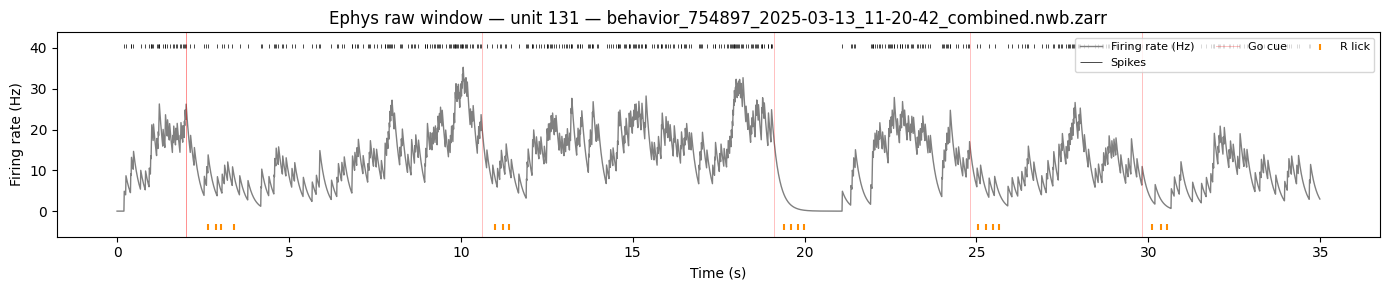

In [73]:
nwb_ephys = load_nwb_from_filename(nwb_path(data_dir, example_ephys))
trials_ephys = nwb_ephys.trials.to_dataframe()
units_ephys  = nwb_ephys.units.to_dataframe()

print(f'{len(units_ephys)} units, {len(trials_ephys)} trials')

# ── pick a tagged unit (opto_tagged_lowbar=True) or the highest-FR unit ───
tagged = units_ephys[units_ephys.get('opto_tagged_lowbar', pd.Series(False, index=units_ephys.index))]
if len(tagged) > 0:
    best_idx = tagged['spike_times'].apply(len).idxmax()
    print(f'Using tagged unit {units_ephys.loc[best_idx, "unit_id"]}')
else:
    best_idx = units_ephys['spike_times'].apply(len).idxmax()
    print('No tagged units; using highest-FR unit')

spike_times_e = units_ephys.loc[best_idx, 'spike_times']
unit_id_e     = units_ephys.loc[best_idx, 'unit_id']

# ── 35 s raw window starting at trial 170 ─────────────────────────────────
trial_start = 170
t_start = trials_ephys['goCue_start_time'].values[trial_start] - 2
t_end   = t_start + 35

go_cues_w = trials_ephys['goCue_start_time'].values
go_cues_w = go_cues_w[(go_cues_w >= t_start) & (go_cues_w <= t_end)]

spikes_w = spike_times_e[(spike_times_e >= t_start) & (spike_times_e <= t_end)] - t_start

# ── PSP kernel (tau_rise=1ms, tau_decay=200ms) ────────────────────────────
step = 0.01
tau_r, tau_d = 0.001, 0.2
n_pts = int((t_end - t_start) / step)
t_smooth = np.arange(n_pts) * step
kt = np.arange(0, 10 * tau_d, step)
psp_e = np.exp(-kt / tau_d) - np.exp(-kt / tau_r)
psp_e /= psp_e.sum() * step
spike_tr = np.zeros(n_pts)
for s in spikes_w:
    idx = int(s / step)
    if 0 <= idx < n_pts:
        spike_tr[idx] = 1
fr_e = np.convolve(spike_tr / step, psp_e * step, mode='full')[:n_pts]

# ── licks ─────────────────────────────────────────────────────────────────
acq = nwb_ephys.acquisition
licks_L = acq['left_lick_time'].timestamps[:] if 'left_lick_time'  in acq else np.array([])
licks_R = acq['right_lick_time'].timestamps[:] if 'right_lick_time' in acq else np.array([])
licks_L = licks_L[(licks_L >= t_start) & (licks_L <= t_end)] - t_start
licks_R = licks_R[(licks_R >= t_start) & (licks_R <= t_end)] - t_start

# ── plot: smoothed FR + spike raster + events ─────────────────────────────
fig, ax = plt.subplots(figsize=(14, 3))
ax.plot(t_smooth, fr_e, color='gray', lw=1, label='Firing rate (Hz)')
ax.eventplot(spikes_w, lineoffsets=fr_e.max() * 1.15, colors='k',
             linewidths=0.5, label='Spikes')
for gc in go_cues_w - t_start:
    ax.axvline(gc, color='red', alpha=0.25, lw=0.7)
ax.axvline(go_cues_w[0] - t_start, color='red', alpha=0.25, lw=0.7, label='Go cue')
if len(licks_L):
    ax.scatter(licks_L, np.full(len(licks_L), -2), color='green',
               marker='|', s=20, label='L lick')
if len(licks_R):
    ax.scatter(licks_R, np.full(len(licks_R), -4), color='darkorange',
               marker='|', s=20, label='R lick')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Firing rate (Hz)')
ax.set_title(f'Ephys raw window — unit {unit_id_e} — {example_ephys}')
ax.legend(fontsize=8, ncol=3)
plt.tight_layout()
plt.show()

In [ ]:
# ── go-cue-aligned raster sorted by first-spike latency ──────────────────
# exact session + unit from F_ephys_behavior_examples FigureE12d_left
raster_session = 'sub-751766_ses-behavior-751766-2025-02-14-11-37-11.nwb'
raster_unit_id = 36

nwb_raster    = load_nwb_from_filename(nwb_path(data_dir, raster_session))
trials_raster = nwb_raster.trials.to_dataframe()
units_raster  = nwb_raster.units.to_dataframe()

spike_times_r = units_raster.loc[units_raster['unit_id'] == raster_unit_id, 'spike_times'].values[0]
print(f'Unit {raster_unit_id}: {len(spike_times_r)} spikes, {len(trials_raster)} trials')

tb, tf = -0.1, 0.5
align_times = trials_raster['goCue_start_time'].values

first_spike = np.full(len(align_times), np.nan)
for i, t0 in enumerate(align_times):
    trial_spikes = spike_times_r[(spike_times_r >= t0) & (spike_times_r <= t0 + tf)] - t0
    if len(trial_spikes) > 0:
        first_spike[i] = trial_spikes.min()

sorted_order = np.argsort(first_spike)   # NaN sorts to end

fig, ax = plt.subplots(figsize=(3, 5))
ax.axvline(0, color='red', ls='--', lw=1, label='Go cue')
for rank, trial_idx in enumerate(sorted_order):
    t0 = align_times[trial_idx]
    spikes_t = spike_times_r[(spike_times_r >= t0 + tb) & (spike_times_r <= t0 + tf)] - t0
    if len(spikes_t):
        ax.vlines(spikes_t, rank - 0.4, rank + 0.4, color='k', lw=0.5)

ax.set_xlim(tb, tf)
ax.set_xlabel('Time from go cue (s)')
ax.set_ylabel('Trials (sorted by first-spike latency)')
ax.set_title(f'Unit {raster_unit_id} — {raster_session[:30]}')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 4. Fiber Photometry — raw trace + go-cue-aligned PSTH (reward vs no-reward)

Data location: `nwb.acquisition`  

In [75]:
nwb_fp = load_nwb_from_filename(nwb_path(data_dir, example_FP))
trials_fp = nwb_fp.trials.to_dataframe()

# ── explore acquisition keys ───────────────────────────────────────────────
# Key format: channel_brain-(region_hemisphere)_detrending-method_motion-correction-or-not
print('Acquisition keys:')
for k, v in nwb_fp.acquisition.items():
    ts = getattr(v, 'timestamps', None)
    n = len(ts) if ts is not None else '?'
    desc = getattr(v, 'description', '')
    print(f'  {k}: {type(v).__name__}, n={n}')
    if desc:
        print(f'    description: {desc}')

Acquisition keys:
  FIP_rising_time: TimeSeries, n=81199
    description: No description
  G-Iso_Gi-L: TimeSeries, n=81199
    description: No description (fiber in Gi-L, channel 2)
  G-Iso_PL-L: TimeSeries, n=81199
    description: No description (fiber in PL-L, channel 0)
  G-Iso_TH-L: TimeSeries, n=81199
    description: No description (fiber in TH-L, channel 1)
  G_Gi-L: TimeSeries, n=81199
    description: No description (fiber in Gi-L, channel 2)
  G_Gi-L_bright: TimeSeries, n=81199
    description: No description (fiber in Gi-L, channel 2)
  G_Gi-L_bright_mc: TimeSeries, n=81199
    description: No description (fiber in Gi-L, channel 2)
  G_Gi-L_exp: TimeSeries, n=81199
    description: No description (fiber in Gi-L, channel 2)
  G_Gi-L_exp_mc: TimeSeries, n=81199
    description: No description (fiber in Gi-L, channel 2)
  G_Gi-L_tri-exp: TimeSeries, n=81199
    description: No description (fiber in Gi-L, channel 2)
  G_Gi-L_tri-exp_mc: TimeSeries, n=81199
    description: No d

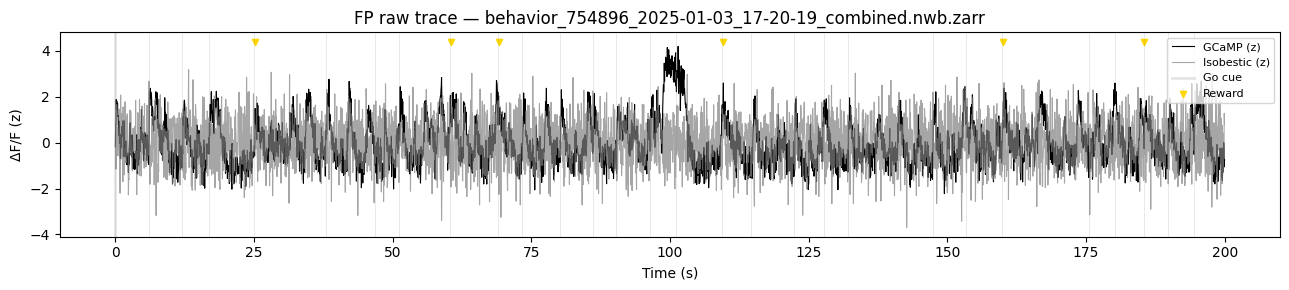

In [76]:
# ── load FP signal — adjust key to match explore output above ─────────────
FP_KEY  = 'G_PL-L_tri-exp_mc'
ISO_KEY = 'Iso_PL-L_tri-exp_mc'

fp_ts    = nwb_fp.acquisition[FP_KEY]
fp_times = fp_ts.timestamps[:]
fp_vals  = fp_ts.data[:]

# ── raw trace: 200 s window ────────────────────────────────────────────────
t0_fp = trials_fp['goCue_start_time'].values[10]
t1_fp = t0_fp + 200
mask_win = (fp_times >= t0_fp) & (fp_times <= t1_fp)
t_win  = fp_times[mask_win]
fp_win = fp_vals[mask_win]

go_cues_fp = trials_fp['goCue_start_time'].values
go_cues_fp = go_cues_fp[(go_cues_fp >= t0_fp) & (go_cues_fp <= t1_fp)]
reward_times = trials_fp.loc[
    trials_fp['rewarded_historyL'] | trials_fp['rewarded_historyR'],
    'reward_outcome_time'
].values
reward_times = reward_times[(reward_times >= t0_fp) & (reward_times <= t1_fp)]

fig, ax = plt.subplots(figsize=(13, 3))
ax.plot(t_win - t0_fp, zscore(fp_win), color='black', lw=0.8, label='GCaMP (z)')
try:
    iso_vals = nwb_fp.acquisition[ISO_KEY].data[:]   # load all first, then mask
    iso_win  = iso_vals[mask_win]
    ax.plot(t_win - t0_fp, zscore(iso_win), color='gray', lw=0.8, alpha=0.7, label='Isobestic (z)')
except KeyError:
    pass
for gc in go_cues_fp - t0_fp:
    ax.axvline(gc, color='gray', alpha=0.2, lw=0.6)
ax.axvline(go_cues_fp[0] - t0_fp, color='gray', alpha=0.2, lw=2, label='Go cue')
ax.scatter(reward_times - t0_fp, np.full(len(reward_times), zscore(fp_win).max() * 1.05),
           color='gold', marker='v', s=20, label='Reward')
ax.set_xlabel('Time (s)')
ax.set_ylabel('ΔF/F (z)')
ax.set_title(f'FP raw trace — {example_FP}')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [ ]:
example_fp_psth = 'sub-749624_ses-behavior-749624-2025-01-02-13-30-36.nwb'  # m749624d20250102

nwb_fp_psth   = load_nwb_from_filename(nwb_path(data_dir, example_fp_psth))
trials_fp_p   = nwb_fp_psth.trials.to_dataframe()
fp_ts_p       = nwb_fp_psth.acquisition['G_PL-L_tri-exp_mc']
fp_times_p    = fp_ts_p.timestamps[:]
fp_z_p        = zscore(fp_ts_p.data[:], nan_policy='omit')

# ── go-cue-aligned PSTH: reward vs no-reward ──────────────────────────────
rewarded_mask  = (trials_fp_p['rewarded_historyL'] | trials_fp_p['rewarded_historyR']).values
go_mask        = trials_fp_p['animal_response'].values != 2

reward_times_all   = trials_fp_p.loc[rewarded_mask  & go_mask, 'goCue_start_time'].values
noreward_times_all = trials_fp_p.loc[~rewarded_mask & go_mask, 'goCue_start_time'].values

bin_size_fp = 0.1
t_pre_fp, t_post_fp = -1.0, 2.0

mat_rew,   t_bins_fp = align_to_events(fp_z_p, fp_times_p, reward_times_all,   t_pre_fp, t_post_fp, bin_size_fp)
mat_norew, _         = align_to_events(fp_z_p, fp_times_p, noreward_times_all, t_pre_fp, t_post_fp, bin_size_fp)

mean_rew   = np.nanmean(mat_rew,   axis=0)
sem_rew    = np.nanstd(mat_rew,    axis=0) / np.sqrt(np.sum(~np.isnan(mat_rew),   axis=0))
mean_norew = np.nanmean(mat_norew, axis=0)
sem_norew  = np.nanstd(mat_norew,  axis=0) / np.sqrt(np.sum(~np.isnan(mat_norew), axis=0))

fig, ax = plt.subplots(figsize=(5, 3))
ax.axvline(0, color='gray', ls='--', lw=0.8)
ax.plot(t_bins_fp, mean_rew,   color='limegreen', label=f'Reward (n={len(reward_times_all)})')
ax.fill_between(t_bins_fp, mean_rew - sem_rew,   mean_rew + sem_rew,   color='limegreen', alpha=0.3, edgecolor='none')
ax.plot(t_bins_fp, mean_norew, color='gray',      label=f'No reward (n={len(noreward_times_all)})')
ax.fill_between(t_bins_fp, mean_norew - sem_norew, mean_norew + sem_norew, color='gray', alpha=0.3, edgecolor='none')
ax.set_xlabel('Time from go cue (s)')
ax.set_ylabel('ΔF/F (z)')
ax.set_title(f'FP PSTH — reward vs no-reward\n{example_fp_psth}')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()